<a href="https://colab.research.google.com/github/AbdulrahmanB-25/EDA_Project/blob/main/EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("mohammedaldakhil/27k-riyadh-places-raw")
pd.set_option("display.max_rows", None)

Using Colab cache for faster access to the '27k-riyadh-places-raw' dataset.


In [ ]:
print("Path to dataset files:", path)
df=pd.read_csv("/kaggle/input/27k-riyadh-places-raw/final_dataset.csv")
df.head()

Path to dataset files: /kaggle/input/27k-riyadh-places-raw


,Unnamed: 0,fsq_id,name,latitude,longitude,address,category,date_created,name_clean,suspicious_name,price,rating,total_photos,total_ratings,total_tips,tastes,tips
0,0,56e8116d498edadf1c556331,حنين الشام Haneen AlSham (حنين الشام),24.470214,46.273324,NaN,"['Middle Eastern Restaurant', 'Falafel Restaur...",2016-03-15,حنين الشام haneen alsham (حنين الشام),False,$$,7.3,3.0,8.0,NaN,[],[]
1,1,4fc243c9e4b08acaf4f01cb3,Mathaq Cafe (كافيه مذاق),24.471596,46.271654,"King Abdulaziz Rd, Al Muzāḩimīyah","['Coffee Shop', 'Breakfast Spot']",2012-05-27,mathaq cafe (كافيه مذاق),False,$,8.0,3.0,8.0,NaN,[],[]
2,2,4bb04ab2f964a520ea3f3ce3,Dorrat AlTaeef درة الطائف,24.469343,46.273202,"King Faisal St, Al Muzāḩimīyah",['Breakfast Spot'],2010-03-29,dorrat altaeef درة الطائف,False,$,NaN,2.0,NaN,NaN,[],[]
3,3,575fd79b498e91d207e922af,المحكمة العامة بالمزاحمية,24.469106,46.273003,NaN,['Courthouse'],2016-06-14,المحكمة العامة بالمزاحمية,False,NaN,NaN,2.0,NaN,NaN,[],[]
4,4,5bced3a0bd4009002c127c85,Fawal AlTaif,24.469393,46.273380,Al Muzahmiyah,['Restaurant'],2018-10-23,fawal altaif,False,NaN,NaN,NaN,NaN,NaN,[],[]


In [ ]:
food_keywords = [
    "restaurant",
    "cafe",
    "coffee",
    "pizza",
    "burger",
    "sandwich",
    "shawarma",
    "kebab",
    "falafel",
    "bakery",
    "dessert",
    "ice cream",
    "donut",
    "juice",
    "smoothie",
    "bbq",
    "grill",
    "steak",
    "chicken",
    "seafood",
    "diner",
    "bistro",
    "buffet",
    "breakfast",
    "brunch",
    "waffle",
    "pancake",
    "crepe",
    "tea",
    "ramen",
    "sushi",
    "noodle",
    "taco",
    "mexican",
    "italian"
]

In [ ]:
"""
What are the most common food place types in Riyadh?

Which categories have the highest ratings?

Where are restaurants geographically concentrated?

Do expensive restaurants receive better ratings?

Where in Riyadh can people find the greatest variety of food types, and how does that variety change across different price levels?

Try to make the niguberhood catagorys

"""

'\nWhat are the most common food place types in Riyadh?\n\nWhich categories have the highest ratings?\n\nWhere are restaurants geographically concentrated?\n\nDo expensive restaurants receive better ratings?\n\nWhere in Riyadh can people find the greatest variety of food types, and how does that variety change across different price levels?\n\nTry to make the niguberhood catagorys\n\n'

In [ ]:
df_restaurants = df[
    df["category"].str.contains('|'.join(food_keywords), case=False, na=False)
].reset_index(drop=True)
df_restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9289 entries, 0 to 9288
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       9289 non-null   int64  
 1   fsq_id           9289 non-null   object 
 2   name             9289 non-null   object 
 3   latitude         9289 non-null   float64
 4   longitude        9289 non-null   float64
 5   address          8350 non-null   object 
 6   category         9289 non-null   object 
 7   date_created     9288 non-null   object 
 8   name_clean       9289 non-null   object 
 9   suspicious_name  9289 non-null   bool   
 10  price            8536 non-null   object 
 11  rating           4745 non-null   float64
 12  total_photos     7141 non-null   float64
 13  total_ratings    4745 non-null   float64
 14  total_tips       5447 non-null   float64
 15  tastes           9289 non-null   object 
 16  tips             9289 non-null   object 
dtypes: bool(1), fl

In [ ]:
df_restaurants.describe()

,Unnamed: 0,latitude,longitude,rating,total_photos,total_ratings,total_tips
count,9289.000000,9289.000000,9289.000000,4745.000000,7141.000000,4745.000000,5447.000000
mean,14180.906987,24.721081,46.685475,7.823836,783.686318,160.756164,26.696714
std,7896.578782,0.098004,0.097384,0.859114,3810.352669,469.913363,85.138123
min,0.000000,24.461685,46.269028,4.700000,-5.000000,2.000000,1.000000
25%,7513.000000,24.646662,46.622211,7.300000,6.000000,15.000000,2.000000
50%,14418.000000,24.738860,46.687681,7.900000,32.000000,36.000000,5.000000
75%,20301.000000,24.797721,46.755041,8.500000,205.000000,113.000000,17.000000
max,26980.000000,24.967605,46.941929,9.600000,94226.000000,12297.000000,2156.000000


In [ ]:
df_restaurants.duplicated().sum()

np.int64(0)

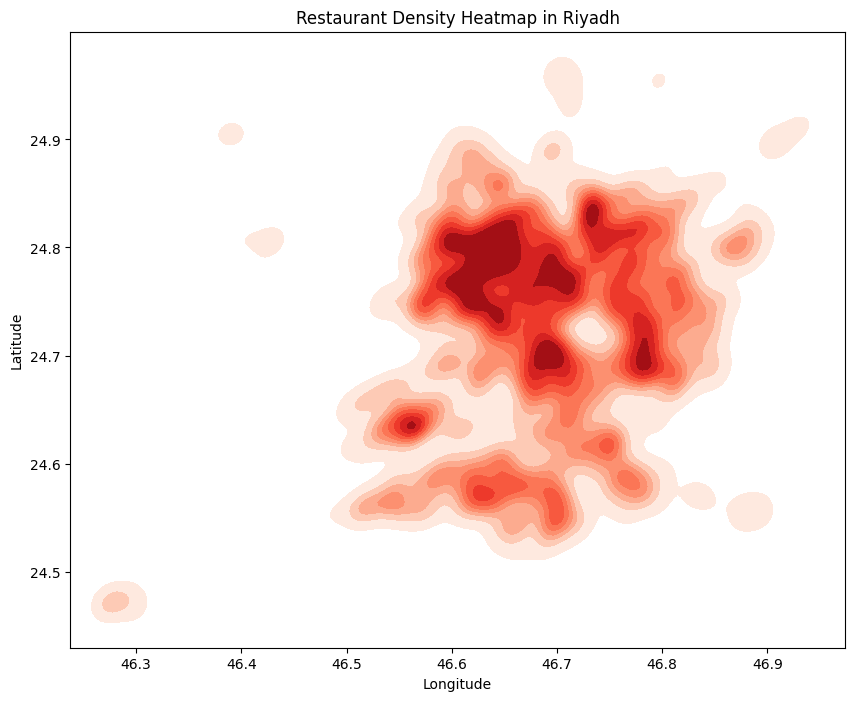

In [ ]:
plt.figure(figsize=(10,8))

sns.kdeplot(
    x=df_restaurants["longitude"],
    y=df_restaurants["latitude"],
    fill=True,
    cmap="Reds",
    bw_adjust=0.5
)

plt.title("Restaurant Density Heatmap in Riyadh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

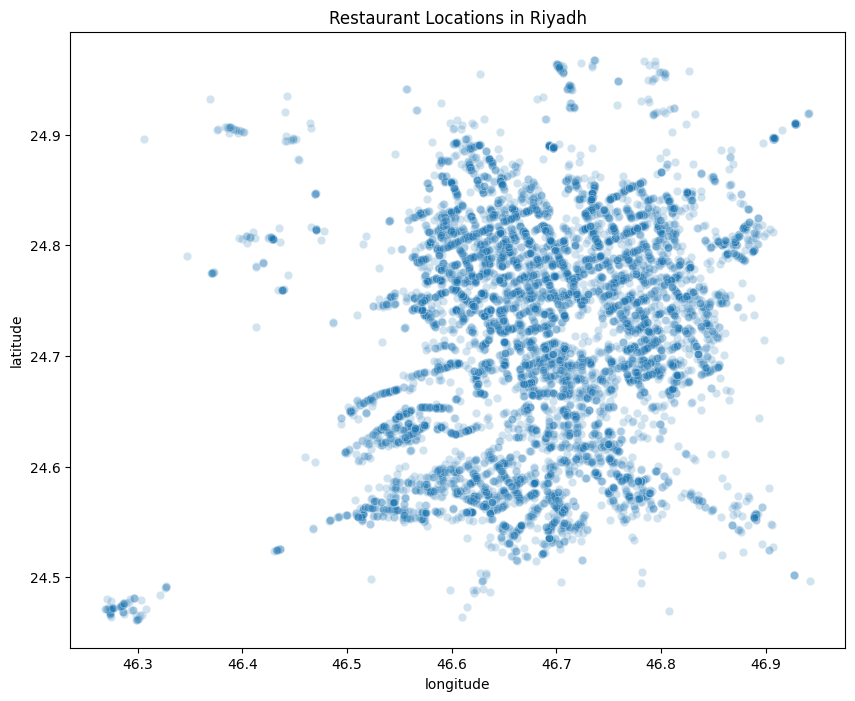

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x="longitude",
    y="latitude",
    data=df_restaurants,
    alpha=0.2
)

plt.title("Restaurant Locations in Riyadh")
plt.show()


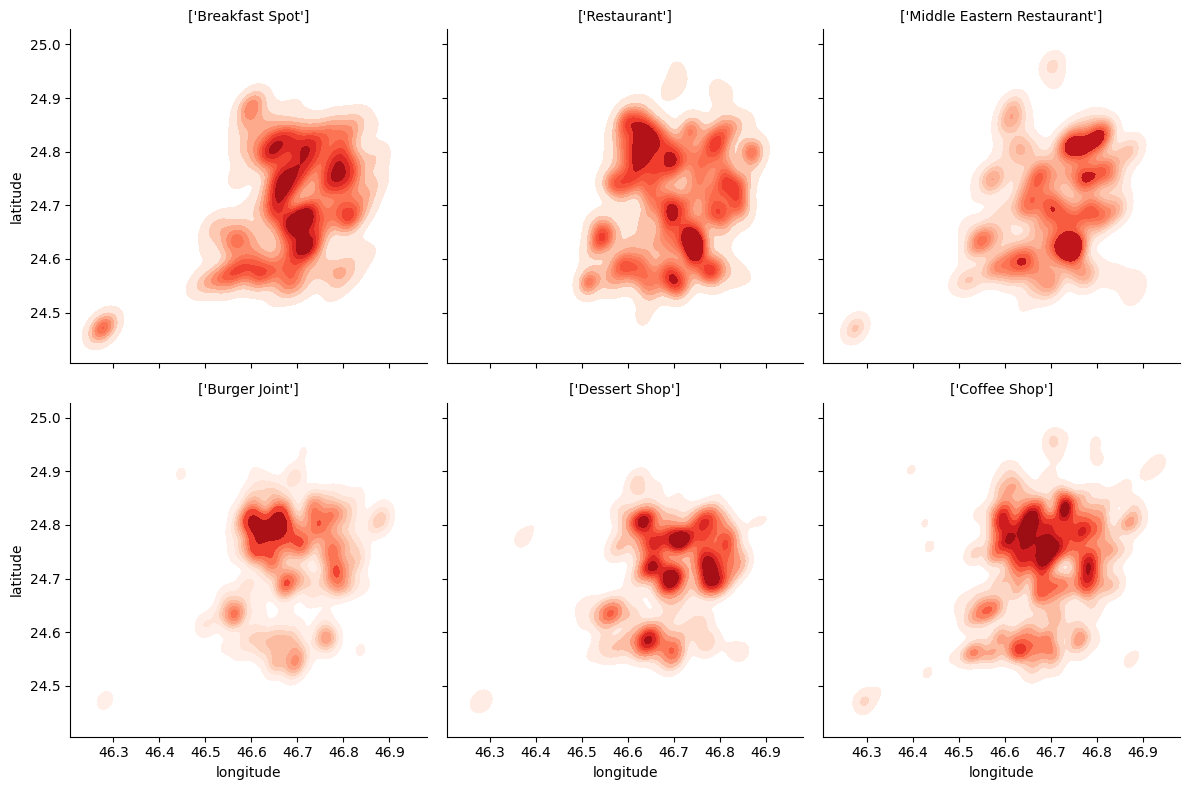

In [ ]:
top_categories = df_restaurants["category"].value_counts().head(6).index
df_top = df_restaurants[df_restaurants["category"].isin(top_categories)]

g = sns.FacetGrid(df_top, col="category", col_wrap=3, height=4)

g.map_dataframe(
    sns.kdeplot,
    x="longitude",
    y="latitude",
    fill=True,
    cmap="Reds",
    bw_adjust=0.5
)

g.set_titles("{col_name}")
plt.show()

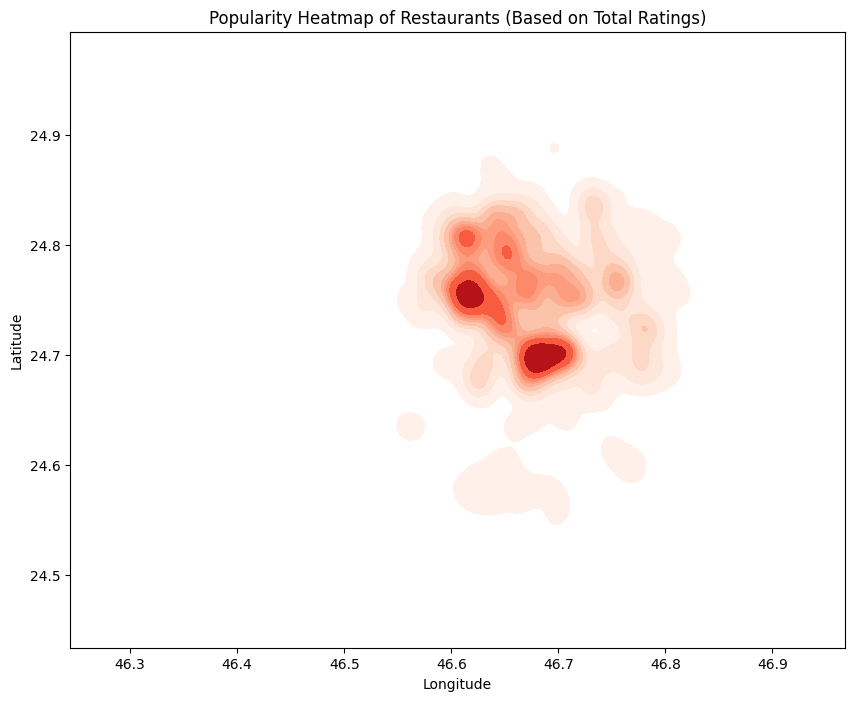

In [ ]:
plt.figure(figsize=(10,8))

sns.kdeplot(
    x=df_restaurants["longitude"],
    y=df_restaurants["latitude"],
    weights=df_restaurants["total_ratings"],
    fill=True,
    cmap="Reds",
    bw_adjust=0.5
)

plt.title("Popularity Heatmap of Restaurants (Based on Total Ratings)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

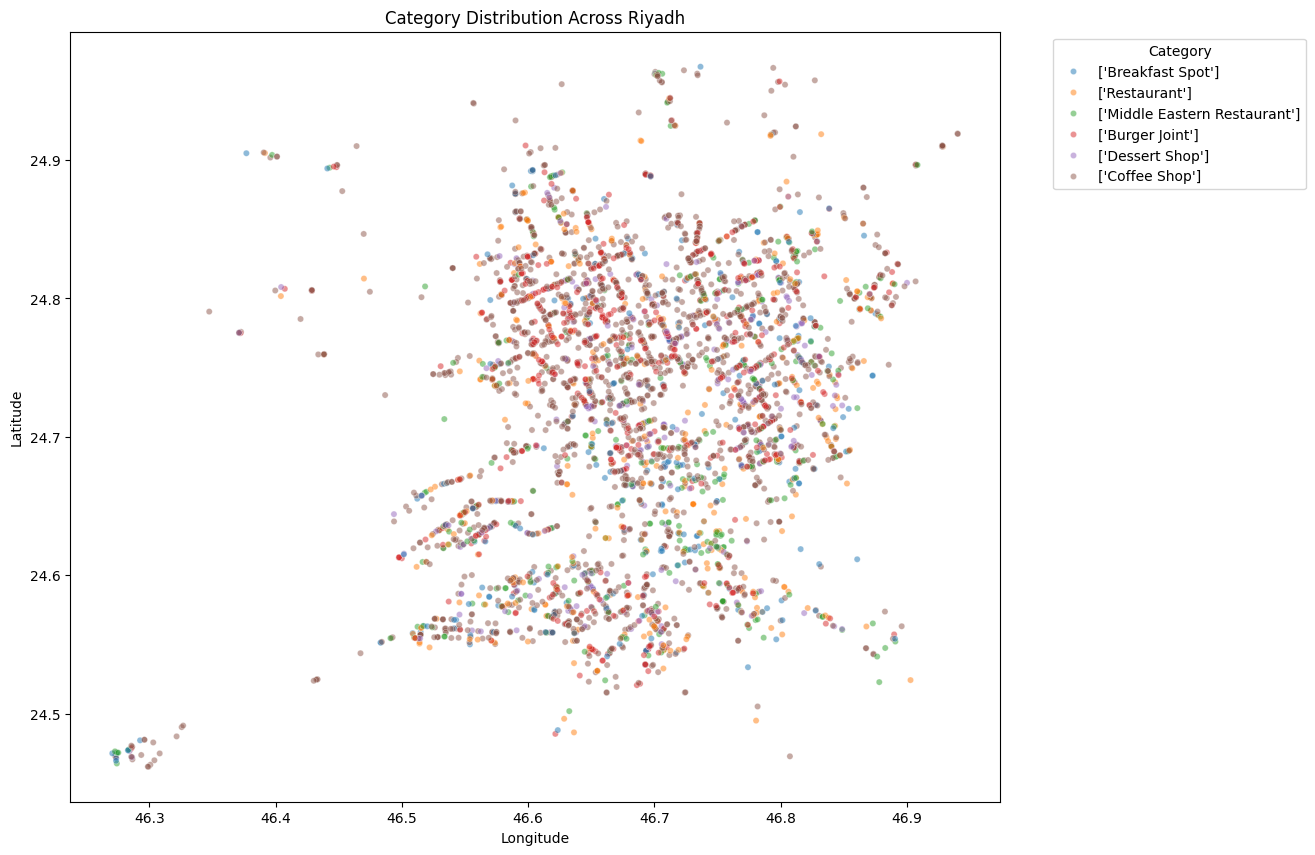

In [108]:
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df_top,
    x="longitude",
    y="latitude",
    hue="category",
    alpha=0.5,
    s=20
)

plt.title("Category Distribution Across Riyadh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Category")
plt.show()